# 01 — Exploratory Data Analysis

Understanding the raw transaction data before any RFM scoring.
We look at distributions, data quality issues, and patterns over time.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_parquet('../data/processed/raw_validated.parquet')
print(f'Shape: {df.shape}')
df.head()

Shape: (1041670, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## Data Quality

In [3]:
print('Null counts:')
print(df.isnull().sum())
print(f'\nCustomer ID missing: {df["Customer ID"].isnull().mean():.1%}')

Null counts:
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    236121
Country             0
dtype: int64

Customer ID missing: 22.7%


In [4]:
print('Dtypes:')
print(df.dtypes)
print('\nBasic stats:')
df[['Quantity', 'Price']].describe().round(2)

Dtypes:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID            object
Country                object
dtype: object

Basic stats:


,Quantity,Price
count,1041670.00,1041670.00
mean,10.96,4.08
std,126.51,51.45
min,1.00,0.00
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.13
max,80995.00,25111.09


## Revenue over time

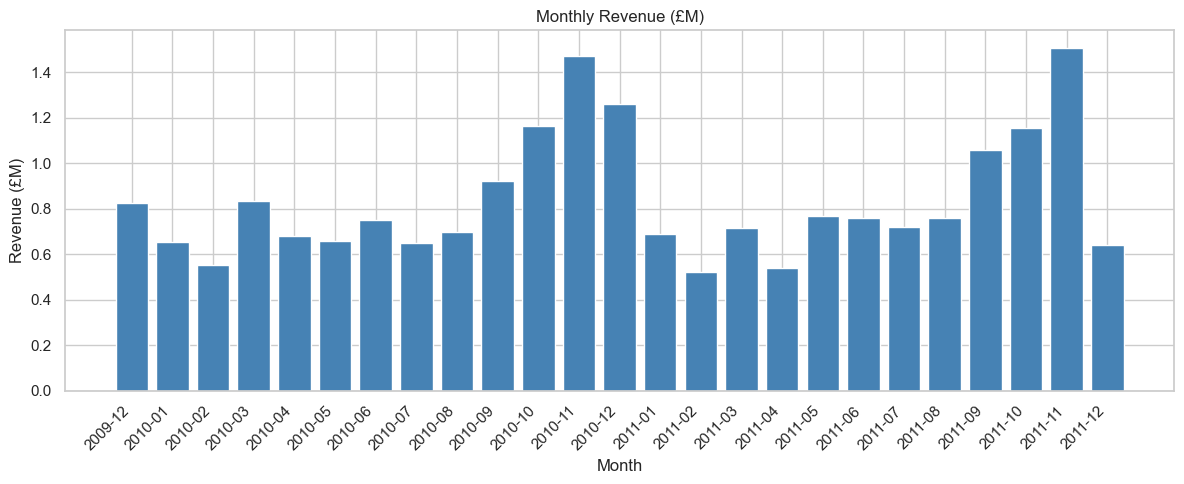

In [5]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly['Month'] = monthly['Month'].astype(str)

fig, ax = plt.subplots()
ax.bar(monthly['Month'], monthly['TotalPrice'] / 1e6, color='steelblue')
ax.set_title('Monthly Revenue (£M)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (£M)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png', dpi=150)
plt.show()

## Orders per country (top 10)

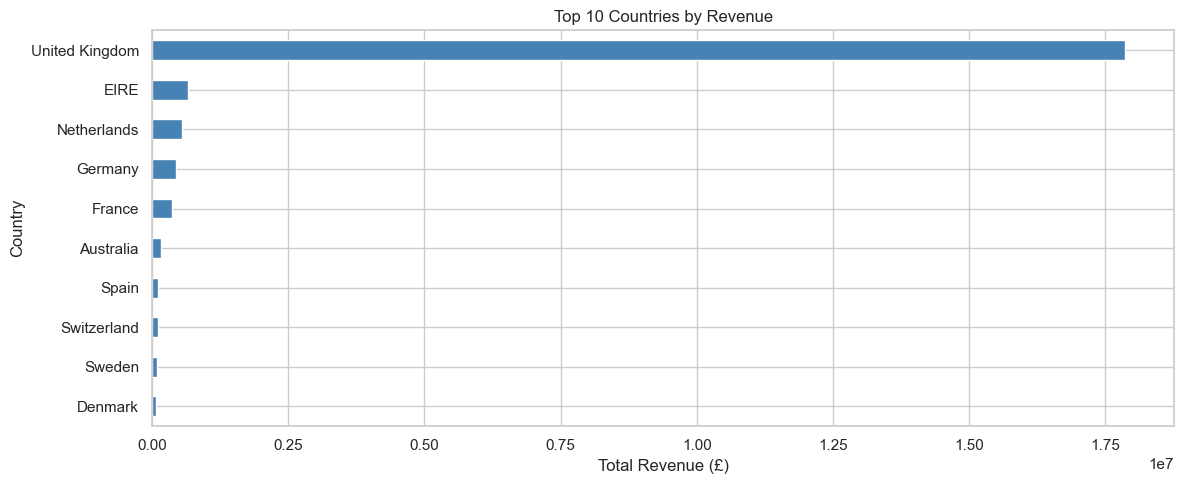

In [6]:
top_countries = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots()
top_countries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Total Revenue (£)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/revenue_by_country.png', dpi=150)
plt.show()

## RFM raw distributions

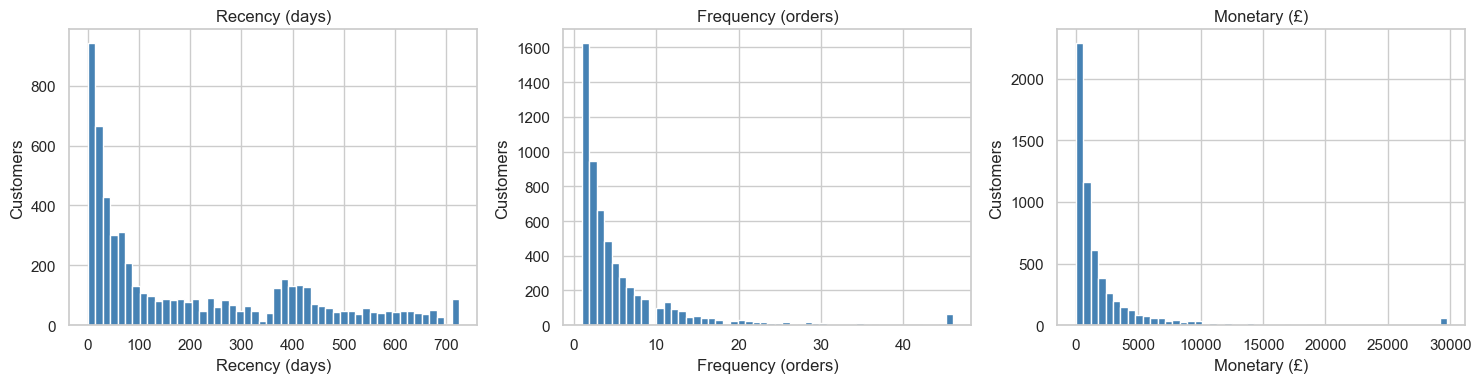

In [7]:
rfm = pd.read_parquet('../data/processed/rfm_features.parquet')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(axes, ['recency', 'frequency', 'monetary'],
                          ['Recency (days)', 'Frequency (orders)', 'Monetary (£)']):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Customers')

plt.tight_layout()
plt.savefig('../outputs/rfm_distributions.png', dpi=150)
plt.show()